In [1]:
import torch
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Torch version: 2.6.0+cu124
CUDA available: True
GPU Name: NVIDIA GeForce RTX 4070 Ti


In [2]:
import rdkit
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys

In [3]:
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM
#from .autonotebook import tqdm as notebook_tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Модель, обученная на 77 млн химических соединений
chem_model_name = "seyonec/ChemBERTa-zinc-base-v1"
chem_tokenizer = AutoTokenizer.from_pretrained(chem_model_name)
chem_model = AutoModel.from_pretrained(chem_model_name).to(device)

def get_smiles_embeddings(smiles_list):
    chem_model.eval()
    embeddings = []
    with torch.no_grad():
        for smi in smiles_list:
            inputs = chem_tokenizer(smi, return_tensors="pt", padding=True, truncation=True).to(device)
            outputs = chem_model(**inputs, output_hidden_states=True)
            # Берем last_hidden_state и усредняем (mean pooling)
            token_emb = outputs.hidden_states[-1]
            mean_emb = token_emb.mean(dim=1)
            embeddings.append(mean_emb.cpu().numpy()[0])
    return np.array(embeddings)

smiles_data = ["NCC(=O)O", "C1=CC=CC=C1"]
smiles_feats = get_smiles_embeddings(smiles_data)
print(f"SMILES Embedding shape: {smiles_feats.shape}") # (2, 768)

/home/admingwi/anaconda3/envs/torch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 539.18it/s, Materializing param=pooler.dense.weight]                             
RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SMILES Embedding shape: (2, 768)


In [4]:
path = 'Data'
folder = 'Toxicity'
data_name = 'Hemotox'
set_name = 'train'
func_y = 'Tox'

In [26]:
path = 'Data'
folder = 'Cell_p'
data_name = 'Cell_p'
set_name = 'train'
func_y = 'CellP'

In [4]:
path = 'Data'
folder = 'Half_life'
data_name = 'Half_life'
set_name = 'train_organ'
#func_y = 'Half-life, h (Homo sapiens)'
func_y = 'Half-life, h'

In [17]:
path = 'Data'
folder = 'Caco'
data_name = 'caco_b'
set_name = 'test'
func_y = 'Caco-2_prm'

In [11]:
path = 'Data'
folder = 'Pampa'
data_name = 'pampa_b'
set_name = 'train'
func_y = 'PAMPA'

In [83]:
path = 'Data'
folder = 'Clearance'
data_name = 'clearance'
set_name = 'train_pept_org'
#func_y = 'Clearance, L/h/kg (Homo sapiens)'
func_y = 'Clearance, L/h/kg'

In [117]:
path = 'Data'
folder = 'Vd'
data_name = 'Vd'
set_name = 'train_hum'
#func_y = 'Clearance, L/h/kg (Homo sapiens)'
func_y = 'Vd, L/kg'

In [119]:
#hl_df = pd.read_csv(f'{path}/{folder}/{data_name}_{set_name}.csv')
hl_df = pd.read_excel(f'{path}/{folder}/{data_name}_{set_name}.xlsx')
hl_df

,sources,Name,Canonical_smiles,"Vd, L/kg","Vd, L/kg (Mus musculus)","Vd, L/kg (Rattus norvegicus)","Vd, L/kg (Macaca fascicularis)","Vd, L/kg (Canis lupus)",Cyclic/Linear (checked),Functional_activity,PK_groups,Canonical/Non-canonical,Sequence,Small,Set
0,chembl,CHEMBL1086218,C/C=C/C[C@@H](C)C(=O)[C@H]1C(=O)N[C@@H](C(C)C)...,1.800,NaN,3.9,NaN,NaN,Cyclic,Противоопухолевое,Группа 4: Рецепторно-сигнальные и таргетные мо...,NaN,NaN,0,Train_Cluster
1,chembl,CHEMBL2103735 (CETRORELIX ACETATE),CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,0.390,NaN,NaN,NaN,NaN,Linear,Гормон,Группа 2: Системные метаболические регуляторы,Non-canonical (неканонические ак),NaN,0,Train_Cluster
2,chembl,CHEMBL114,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2CCCC[C@@H]2CN1C[C...,3.600,NaN,3.0,NaN,NaN,Linear,Saquinavir,NaN,NaN,NaN,0,Train_Cluster
3,chembl,CHEMBL1652593,CCC(C)CCCCC(=O)N[C@@H](CCN)C(=O)N[C@H](C(=O)N[...,0.193,NaN,NaN,NaN,NaN,Cyclic,NaN,NaN,NaN,NaN,0,Train_Cluster
4,chembl,CHEMBL4744444,CCCCCCCCCC(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N...,0.090,NaN,NaN,NaN,NaN,Cyclic,NaN,NaN,NaN,NaN,0,Train_Cluster
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,"thpdb, drugbank, chembl, stability",Teriparatide,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,0.120,NaN,NaN,NaN,NaN,Linear,Гормон,Группа 2: Системные метаболические регуляторы,Canonical,SVSEIQLMHNLGKHLNSMERVEWLRKKLQDVHNF,0,Train_Cluster
88,"thpdb, drugbank, PepMSND",Salmon Calcitonin,CC(C)C[C@H](NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@...,0.225,NaN,NaN,NaN,NaN,Cyclic,Гормон,Группа 2: Системные метаболические регуляторы,Non-canonical (терминальные модификации),CSNLSTCVLGKLSQELHKLQTYPRTNTGSGTP-NH2,0,Train_Cluster
89,"thpdb, drugbank, PepMSND",Bivalirudin,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,0.200,NaN,NaN,NaN,NaN,Linear,"Средства, влияющие на свёртывание крови и фибр...",Группа 1: Эффекторы «острой фазы»,Non-canonical (D-ак),fPRPGGGGNGDFEEIPEEYL,0,Test_Cluster
90,"thpdb, drugbank, stability",Abaloparatide,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCC...,0.714,NaN,NaN,NaN,NaN,Linear,Гормон,Группа 2: Системные метаболические регуляторы,"Non-canonical (неканонические ак, терминальные...",AVSEHQLLHDKGKSIQDLRRRELLEKLL-Aib-KLHTA-NH2,0,Train_Cluster


<Axes: >

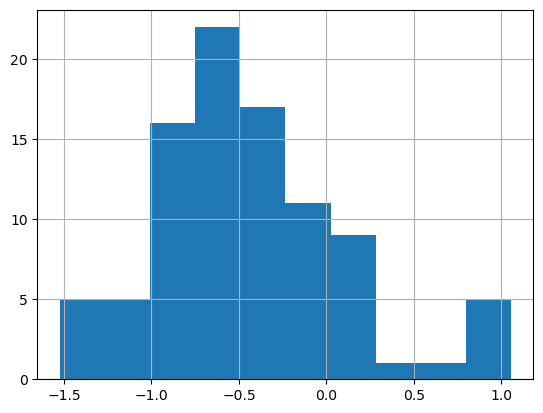

In [120]:
hl_df['y'] = np.log10(hl_df[func_y])
hl_df['y'].hist()

In [87]:
def prepare_final_dataset(df):
    # Рассчитываем логарифм, если его еще нет
    # Добавляем небольшое смещение (1e-6), чтобы избежать log(0)
    df['y'] = np.log10(df[func_y] + 1e-6)

    # Фильтрация согласно вашему графику
    # Оставляем только "здоровое" распределение
    df_filtered = df[(df['y'] >= -4) & (df['y'] <= 2)].copy()
    
    print(f"Удалено выбросов: {len(df) - len(df_filtered)}")
    print(f"Осталось образцов для обучения: {len(df_filtered)}")
    
    return df_filtered

# Очищаем
hl_df = prepare_final_dataset(hl_df)
hl_df = hl_df.reset_index(drop=True)

Удалено выбросов: 55
Осталось образцов для обучения: 716


In [110]:
categories = ['Homo sapiens', 'Rattus norvegicus', 'Mus musculus', 'Macaca fascicularis', 'Canis lupus']  # Порядок важен!
mapping = {cat: i for i, cat in enumerate(categories)}
hl_df['Org_ind'] = hl_df['Organism'].map(mapping)
hl_df

,sources,Name,Canonical_smiles,Cyclic/Linear (checked),Functional_activity,PK_groups,Canonical/Non-canonical,Sequence,Small,Set,Столбец 1,Organism,"Vd, L/kg",is_Canis lupus,is_Homo sapiens,is_Macaca fascicularis,is_Mus musculus,is_Rattus norvegicus,y,Org_ind
0,chembl,CHEMBL1086218,C/C=C/C[C@@H](C)C(=O)[C@H]1C(=O)N[C@@H](C(C)C)...,Cyclic,Противоопухолевое,Группа 4: Рецепторно-сигнальные и таргетные мо...,NaN,NaN,0,Train_All_Available,NaN,Homo sapiens,1.800,False,True,False,False,False,0.255273,0
1,chembl,CHEMBL2103735 (CETRORELIX ACETATE),CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,Linear,Гормон,Группа 2: Системные метаболические регуляторы,Non-canonical (неканонические ак),NaN,0,Train_All_Available,NaN,Homo sapiens,0.390,False,True,False,False,False,-0.408935,0
2,chembl,CHEMBL114,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2CCCC[C@@H]2CN1C[C...,Linear,Saquinavir,NaN,NaN,NaN,0,Train_All_Available,NaN,Homo sapiens,3.600,False,True,False,False,False,0.556303,0
3,chembl,CHEMBL1652593,CCC(C)CCCCC(=O)N[C@@H](CCN)C(=O)N[C@H](C(=O)N[...,Cyclic,NaN,NaN,NaN,NaN,0,Train_All_Available,NaN,Homo sapiens,0.193,False,True,False,False,False,-0.714443,0
4,chembl,CHEMBL4744444,CCCCCCCCCC(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N...,Cyclic,NaN,NaN,NaN,NaN,0,Train_All_Available,NaN,Homo sapiens,0.090,False,True,False,False,False,-1.045757,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,Small_data,Flucozole,OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1F,NaN,NaN,NaN,NaN,NaN,1,Unused,NaN,Canis lupus,0.700,True,False,False,False,False,-0.154902,4
1661,Small_data,Fluphezine,OCCN1CCN(CCCN2c3ccccc3Sc3ccc(C(F)(F)F)cc32)CC1,NaN,NaN,NaN,NaN,NaN,1,Unused,NaN,Canis lupus,5.500,True,False,False,False,False,0.740363,4
1662,Small_data,Butorphanol,Oc1ccc2c(c1)[C@]13CCCC[C@@]1(O)[C@H](C2)N(CC1C...,NaN,NaN,NaN,NaN,NaN,1,Unused,NaN,Canis lupus,8.400,True,False,False,False,False,0.924279,4
1663,Small_data,Trovafloxacin,[NH3+]C1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)[O-])...,NaN,NaN,NaN,NaN,NaN,1,Unused,NaN,Canis lupus,1.370,True,False,False,False,False,0.136721,4


In [121]:
hl_df['Org_ind'] = 0.0

In [122]:
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM
#from .autonotebook import tqdm as notebook_tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


chem_model_name = "seyonec/ChemBERTa-zinc-base-v1"
chem_tokenizer = AutoTokenizer.from_pretrained(chem_model_name)
chem_model = AutoModel.from_pretrained(chem_model_name).to(device)
# Настройки
BATCH_SIZE = 1 # Настройте под объем памяти вашей видеокарты (16, 32 или 64)

# Список всех SMILES
smiles_list = hl_df['Canonical_smiles'].tolist()
print(len(smiles_list))

# Создаем DataLoader для автоматического разбиения на пакеты
dataloader = DataLoader(smiles_list, batch_size=BATCH_SIZE, shuffle=False)

x = []

print(f"Начинаю обработку {len(smiles_list)} структур на {device}...")

for batch in tqdm(dataloader):
    # Токенизация пакета
    inputs = chem_tokenizer(
        batch, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=512
    ).to(device)
    
    with torch.no_grad():
        outputs = chem_model(**inputs)
        batch_embeddings = outputs.last_hidden_state[:, 0, :]
            
    # Переносим результат на CPU и добавляем в общий список
    x.append(batch_embeddings.cpu().numpy())

# Объединяем список массивов в одну итоговую матрицу (N, 768)
x = np.vstack(x)
print(x.shape)
# Если вам нужно сохранить и целевую переменную y, сохраняя порядок:
#y = hl_df['Half-life, h'].values

print(f"Готово! Размер матрицы признаков: {x.shape}")
x_df = pd.DataFrame(x)
x_df['Smiles'] = hl_df['Canonical_smiles']
x_df['y'] = hl_df['y']
#x_df['y'] = np.log10(hl_df[func_y])
# categories
x_df['Org_ind'] = hl_df['Org_ind']

x_df.to_csv(f'{path}/{folder}/{data_name}_{set_name}_chemberta.csv', index=None)

Using device: cuda


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 652.00it/s, Materializing param=pooler.dense.weight]                             
RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


92
Начинаю обработку 92 структур на cuda...


100%|██████████| 92/92 [00:00<00:00, 138.07it/s]

(92, 768)
Готово! Размер матрицы признаков: (92, 768)


In [90]:
x_df

,0,1,2,3,4,5,6,7,8,9,...,761,762,763,764,765,766,767,Smiles,y,Org_ind
0,1.990669,0.110756,-1.279236,-1.505922,0.484261,-1.659420,-0.141646,-0.218268,-0.652643,-0.619899,...,-1.985544,1.297847,0.725144,-1.257740,-0.379164,-0.537951,0.153606,C/C=C/C[C@@H](C)C(=O)[C@H]1C(=O)N[C@@H](C(C)C)...,-0.806873,0
1,2.378549,0.847289,-0.181322,-0.170630,0.480488,-0.723776,1.191437,-0.479378,-0.184230,0.387799,...,-1.166292,-0.525072,-0.263266,-0.497139,0.257661,-1.209417,-0.088270,CC(=O)N(C)C1(c2ccccc2)CCN(C[C@@H]2C[C@@]2(C(=O...,1.211807,0
2,2.485313,1.548082,-0.448827,-0.477364,0.773236,-0.550268,0.798968,-0.055438,-0.060099,-0.568427,...,-0.425229,-0.208006,-0.695749,-1.040787,0.575071,-0.663794,0.813461,CC(=O)NC1(c2ccccc2)CCN(C[C@@H]2C[C@@]2(C(=O)N(...,0.417353,0
3,0.855517,-0.106582,-1.479132,-1.122707,-0.824169,-0.931594,-0.760059,0.099451,-0.561345,-0.749145,...,-1.604270,0.066621,0.628633,0.061169,-0.689417,-0.646151,0.260974,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,-1.142661,0
4,1.559661,0.017001,-0.715133,-1.435942,-0.745919,-1.056816,-0.903597,0.024079,-0.927864,-0.304957,...,-2.070691,0.915496,-0.163037,-0.732231,-0.604005,-0.107621,0.491993,CC(=O)O.CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=...,-0.920815,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,2.556248,0.246942,-1.539455,-0.132990,0.447206,-0.860145,-0.407355,-0.122694,-0.409560,-0.871529,...,-1.214114,0.580636,0.691301,-0.560012,-0.332419,-1.005429,0.158028,NC(=O)[C@H](Cc1ccc(Cl)c(Cl)c1)NC(=O)CN1C(=O)C(...,0.296665,4
712,0.131775,0.070884,-0.368891,0.104355,0.303013,-0.995223,-0.351432,-0.620303,-0.670831,-1.142859,...,-0.289273,0.708361,0.937912,-1.112049,-1.609967,-0.606952,0.444218,O=C(CN1CCCC1=O)NCc1cc2cc(C(=O)N3CCC(N4C(=O)OCc...,0.309630,4
713,1.036631,-0.056039,-0.259254,-1.568411,-1.143152,-0.914726,-1.175499,0.410203,-1.767514,-0.508841,...,-1.395285,0.529737,-0.769654,-0.311913,-0.821960,-0.004145,0.283325,CCCCCOc1ccc(-c2cc(-c3ccc(C(=O)N[C@H]4C[C@@H](O...,-1.329745,4
714,2.045493,0.183939,-0.889426,-1.519926,0.103925,-1.785452,0.010847,-0.019209,-1.162259,-0.528097,...,-1.879833,1.354428,0.319132,-1.076968,-0.266332,-0.455567,0.162051,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,-0.313363,4


In [47]:
hl_df['Canonical_smiles']

0      C/C=C/C[C@@H](C)C(=O)[C@H]1C(=O)N[C@@H](C(C)C)...
2      CC(=O)N(C)C1(c2ccccc2)CCN(C[C@@H]2C[C@@]2(C(=O...
3      CC(=O)NC1(c2ccccc2)CCN(C[C@@H]2C[C@@]2(C(=O)N(...
4      CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...
5      CC(=O)O.CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=...
                             ...                        
166    CN(Cc1ccc(F)cc1)C(=O)[C@@]1(c2ccc(Cl)c(Cl)c2)C...
167    CN(Cc1ccccc1)C(=O)[C@@]1(c2ccc(Cl)c(Cl)c2)C[C@...
168    CNCCCC[C@H]1C(=O)N[C@@H](CC(C)C)C(=O)N2CCC[C@@...
172    CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...
177    N=C(N)N1CCC[C@@H](CNC(=O)C[C@H](NS(=O)(=O)c2cc...
Name: Canonical_smiles, Length: 125, dtype: object